In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Assignment 4

Deadline: 22.04.2026 12:00 CET

<Add your name, student-id and emal address>

## Prerequisites: Library imports, data load and initialization of the backtest service

In [13]:
# Standard library imports
import os
import sys
import copy
from typing import Optional
from pathlib import Path

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
current_dir = Path(os.getcwd())
project_root = current_dir.parent
src_path = project_root / 'src'

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest
from backtesting.strategy import Strategy
from backtesting.portfolio import Portfolio

In [14]:
PATH_TO_DATA = '/Users/oscar/Documents/QPWP/qpmwp-course/data/'     # <CHANGE THIS TO YOUR PATH TO DATA>

In [15]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(f'{PATH_TO_DATA}market_data.parquet', read_dictionary=[])
jkp_data = pd.read_parquet(f'{PATH_TO_DATA}jkp_data.parquet', read_dictionary=[])


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [16]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [17]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return
        self._mu = None
        self._cov = None
        self._optimization_data = None

    def set_objective(self, optimization_data: OptimizationData) -> None:
        # Store optimization data and precompute mu and covariance aligned to constraint ids
        X = optimization_data['return_series']
        ids = self.constraints.ids

        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        # Ensure pandas objects for alignment
        mu_s = pd.Series(mu, index=X.columns) if not isinstance(mu, pd.Series) else mu.copy()
        cov_df = pd.DataFrame(covmat, index=X.columns, columns=X.columns) if not isinstance(covmat, pd.DataFrame) else covmat.copy()

        # Align to constraint ids
        mu_aligned = mu_s.loc[ids].to_numpy()
        cov_aligned = cov_df.loc[ids, ids].to_numpy()

        self._mu = mu_aligned
        self._cov = cov_aligned
        self._optimization_data = optimization_data

        # initialize objective with default risk aversion
        risk_av = self.params.get('risk_aversion', 1.0)
        self.objective = Objective(q = -self._mu, P = self._cov * 2 * risk_av)
        return None

    def solve(self) -> None:
        # Iteratively adjust risk aversion to approximate max Sharpe under constraints
        max_iter = int(self.params.get('max_iter', 10))
        tol = float(self.params.get('tol', 1e-6))
        # initial risk aversion
        lam = float(self.params.get('risk_aversion', 1.0))

        # require precomputed mu and cov
        if self._mu is None or self._cov is None or self._optimization_data is None:
            raise ValueError('Call set_objective(...) before solve().')

        ids = self.constraints.ids

        for i in range(max_iter):
            # update objective for current lambda
            self.params['risk_aversion'] = lam
            self.objective = Objective(q = -self._mu, P = self._cov * 2 * lam)

            # solve the quadratic program (updates self.results)
            super().solve()

            # extract weights in correct order
            w_dict = self.results.get('weights', {})
            w = pd.Series(w_dict).loc[ids].to_numpy()

            mu_p = float(self._mu @ w)
            var_p = float(w.T @ self._cov @ w)

            if var_p <= 0 or np.isnan(var_p) or np.isclose(var_p, 0):
                break

            lam_new = mu_p / var_p

            # check convergence
            if abs(lam_new - lam) / (abs(lam) + 1e-12) < tol:
                lam = lam_new
                break

            lam = lam_new

        # final store
        self.params['risk_aversion'] = lam
        self.results.update({'risk_aversion': lam})
        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [18]:
bs.optimization = MaxSharpe(
     covariance=Covariance(method='pearson'),
     expected_return=ExpectedReturn(method='geometric'),
     solver_name='osqp',  # <change this to your preferred solver>
     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
 )
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

bs.optimization.results


{'weights': {'102': -0.00039261878493203274,
  '103': -0.0002881403586986429,
  '104': -0.00027560242552398173,
  '111': -4.3137519053632856e-05,
  '120': 0.04985028420177326,
  '122': -0.00028744180016614156,
  '125': -0.0003113947073073711,
  '126': -0.0002630785484655263,
  '127': 0.09989898724970042,
  '128': -0.00010892355727116434,
  '129': -0.0004073379239326661,
  '134': -0.00028925116087927184,
  '136': -0.0001922449538562504,
  '139': -0.00048606322578111593,
  '141': -0.00019949187886270707,
  '142': -0.00034797254499190083,
  '148': -0.00018660580139405936,
  '149': -0.0003976519133778437,
  '154': 0.09985420173108363,
  '159': -0.00018315286242385294,
  '161': -0.0001792147127732212,
  '169': -0.0004132086417221531,
  '170': 0.019700984816352123,
  '174': -0.0001832059314491227,
  '175': -0.00037047061887922046,
  '176': -0.0002642269357934564,
  '177': 0.0495136273737825,
  '184': -1.4942604396911602e-05,
  '185': -0.0004727098630693831,
  '191': -0.00011013559754697389,


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [19]:
# 1. Setup trial values
trial_taus = [0.0001, 0.0003, 0.0005, 0.001, 0.1, 0.5]
subset_dates = rebdates[:12] # Use a few dates for speed
rebal_per_year = 4 # n_month = 3

for tau in trial_taus:
    # Update the optimizer with the trial penalty
    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='osqp',
        turnover_penalty=tau
    )
    
    # Create a fresh Strategy object for each trial
    temp_strategy = Strategy([])

    for date in subset_dates:
        # Manually prepare the data/constraints for this date
        bs.prepare_rebalancing(rebalancing_date=date, strategy=temp_strategy)

        # Solve the problem
        bs.optimization.set_objective(optimization_data=bs.optimization_data)
        bs.optimization.solve()

        # Store the resulting weights in a Portfolio object
        portfolio = Portfolio(
            rebalancing_date=date,
            weights=bs.optimization.results['weights']
        )
        temp_strategy.portfolios.append(portfolio)

    # Calculate average turnover and annualize it
    ret_series = bs.data.get_return_series(weekdays_only=False)
    avg_to = temp_strategy.turnover(return_series=ret_series).mean()
    ann_to = avg_to * rebal_per_year
    
    print(f"Tau: {tau:.4f} | Annualized Turnover: {ann_to:.2%}")

Tau: 0.0001 | Annualized Turnover: 133.99%
Tau: 0.0003 | Annualized Turnover: 106.17%
Tau: 0.0005 | Annualized Turnover: 89.63%
Tau: 0.0010 | Annualized Turnover: 72.24%
Tau: 0.1000 | Annualized Turnover: 65.07%
Tau: 0.5000 | Annualized Turnover: 63.55%


In [20]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='osqp',     # optionally, change this to your preferred solver
    turnover_penalty=0.0002,    # <your code here>
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

final_to = bt_ms.strategy.turnover(return_series=bs.data.get_return_series()).mean() * (12/3)
print(f"Final Annualized Turnover: {final_to:.2%}")

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

## 3. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


<Axes: title={'center': 'Cumulative Returns'}>

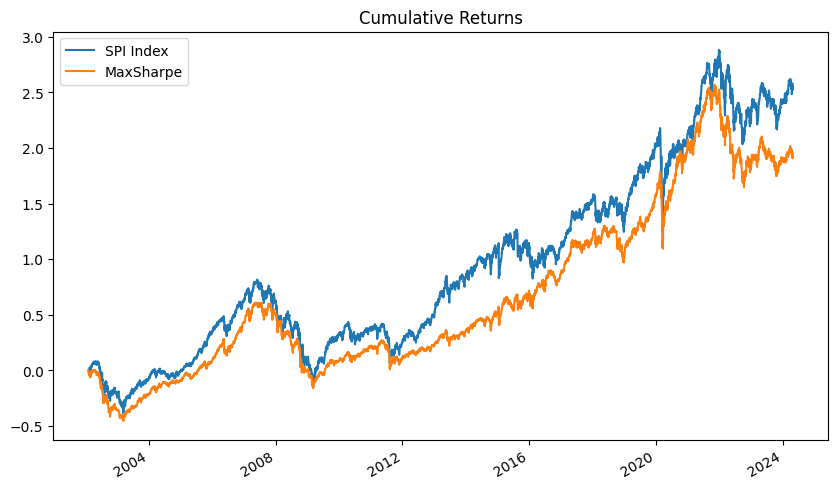

In [24]:
fixed_costs = 0.01 
variable_costs = 0.003 
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

# Plot the cumulative returns of the strategy and the benchmark
sim_cum = (1 + sim).cumprod() - 1
sim_cum.rename(columns={'bm': 'SPI Index', 'ms': 'MaxSharpe'}).plot(
    title='Cumulative Returns', 
    figsize=(10, 6))

<Axes: title={'center': 'Turnover'}>

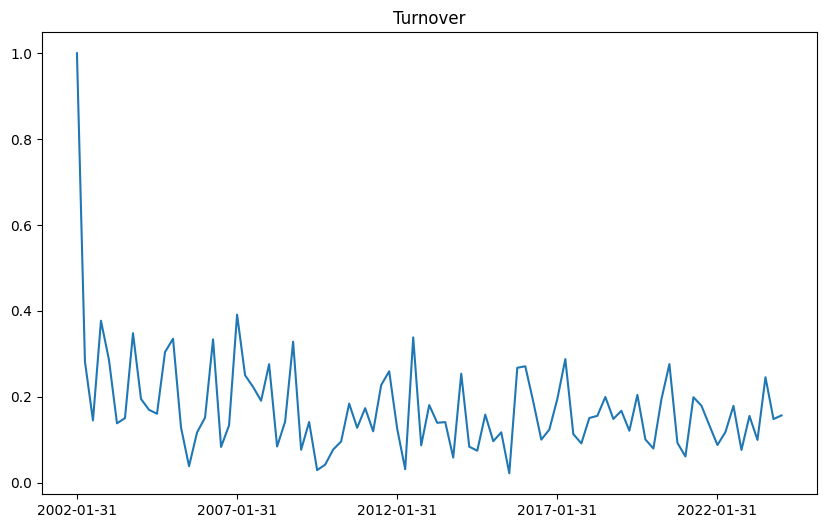

In [25]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [26]:

# Annualized turnover per annum (pa) in percentage
to_pa = to_ms.mean() * (12 / n_month) # <your code here>
print(f"The annualized turnover is: {to_pa:.2%}")

The annualized turnover is: 70.10%


In [29]:
# Decriptive statistics

trading_days = 252
annual_return = {}
cumulative_return = {}
annual_volatility = {}
sharpe_ratio = {}
max_drawdown = {}

for column in sim.columns:
    returns = sim[column].dropna()
    n_obs = len(returns)
    cumulative_curve = (1 + returns).cumprod()

    cumulative_return[column] = cumulative_curve.iloc[-1] - 1
    annual_return[column] = cumulative_curve.iloc[-1] ** (trading_days / n_obs) - 1
    annual_volatility[column] = returns.std() * np.sqrt(trading_days)

    if returns.std() > 0:
        sharpe_ratio[column] = returns.mean() / returns.std() * np.sqrt(trading_days)
    else:
        sharpe_ratio[column] = np.nan

    drawdown = cumulative_curve / cumulative_curve.cummax() - 1
    max_drawdown[column] = drawdown.min()

stats = pd.concat([
    pd.DataFrame(annual_return, index=['Annual Return']),
    pd.DataFrame(cumulative_return, index=['Cumulative Return']),
    pd.DataFrame(annual_volatility, index=['Annual Volatility']),
    pd.DataFrame(sharpe_ratio, index=['Sharpe Ratio']),
    pd.DataFrame(max_drawdown, index=['Max Drawdown']),
])

stats = stats.rename(columns={'bm': 'SPI Index', 'ms': 'MaxSharpe'}).astype(object)

stats.loc[['Annual Return', 'Cumulative Return', 'Annual Volatility', 'Max Drawdown']] = (
    stats.loc[['Annual Return', 'Cumulative Return', 'Annual Volatility', 'Max Drawdown']]
    .map(lambda x: f'{x:.2%}')
)

stats.loc['Sharpe Ratio'] = stats.loc['Sharpe Ratio'].map(lambda x: f'{x:.2f}')
print(stats)


                  SPI Index MaxSharpe
Annual Return         5.56%     4.71%
Cumulative Return   253.25%   192.42%
Annual Volatility    16.47%    12.55%
Sharpe Ratio           0.41      0.43
Max Drawdown        -53.25%   -47.88%
